## Requirements

- **Python ≥ 3.11** — geopandas 1.x and fiona 1.10+ require Python 3.11+
- **Packages:** `pip install requests rasterio numpy matplotlib pystac-client geopandas pyproj`
- **Network:** HTTP access to `kanopia.org` (STAC API) and `lab.kanopia.org` (COG files, GeoPackage)
- **Credentials:** Basic Auth required for COG files — set `COG_USER` / `COG_PASS` in the config cell

# BCI COG Workshop

This notebook demonstrates:
1. Querying the Kanopia **STAC API** to find BCI drone imagery by date
2. Reading a tiny window from a **50 GB+ Cloud Optimized GeoTIFF** in ~2 seconds
3. Computing **RGB vegetation indices** (GLI, VARI, GCC) to detect dead trees
4. Comparing the **same tree across two dates** to see change over time

---
**Run this notebook top-to-bottom.** Each cell builds on the previous one.

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
STAC_API_URL  = "https://kanopia.org/stac-fastapi-pgstac/api/v1/pgstac/"
COLLECTION_ID = "2024_bci"

# Workshop credentials
COG_USER = "panama"
COG_PASS = "panama123"

# Dead tree to track (from field datasheet — tag surveyed as dead/dying in 2024)
TARGET_TREETAG    = "6949"
TARGET_POLYGON_ID = 1041

# Path to field datasheet GeoPackage (relative to this notebook)
import os
GPKG_PATH = os.environ.get(
    "GPKG_PATH",
    "https://lab.kanopia.org/share/public/2024-05-14_2024-06-11_fieldDatasheet.gpkg"
)

print("STAC endpoint  :", STAC_API_URL)
print("Collection     :", COLLECTION_ID)
print("Target tree tag:", TARGET_TREETAG)
print("GeoPackage path:", GPKG_PATH)

In [13]:
# ── Install packages (safe to re-run) ────────────────────────────────────────
import sys, subprocess
pkgs = ["requests", "rasterio", "numpy", "matplotlib",
        "pystac-client", "geopandas", "pyproj"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "-q"])
print("Packages ready.")

Packages ready.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
# ── Imports + GDAL network settings ──────────────────────────────────────────
import os, re
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from pyproj import Transformer
from pystac_client import Client
from urllib.parse import urlparse, urlunparse

# Tune GDAL for slower networks
os.environ.setdefault("GDAL_HTTP_TIMEOUT",        "120")
os.environ.setdefault("GDAL_HTTP_MAX_RETRY",      "3")
os.environ.setdefault("GDAL_HTTP_RETRY_DELAY",    "5")
os.environ.setdefault("GDAL_DISABLE_READDIR_ON_OPEN", "EMPTY_DIR")

print("Imports OK.")

Imports OK.


In [15]:
# ── Helper functions ──────────────────────────────────────────────────────────
def add_auth(url, user, pwd):
    """Embed Basic Auth credentials into a URL."""
    p = urlparse(url)
    if p.username:
        return url
    netloc = f"{user}:{pwd}@{p.netloc}"
    return urlunparse((p.scheme, netloc, p.path, p.params, p.query, p.fragment))


def read_rgb_chip(href, x, y, user, pwd, src_crs="EPSG:4326", chip_px=512):
    """Read a chip_px x chip_px RGB window from a COG, centered on point (x, y) in src_crs.

    src_crs defaults to WGS84 (lon/lat). Pass the GeoPackage CRS when coordinates
    come directly from a GeoPackage to avoid a double reprojection.
    """
    url = add_auth(href, user, pwd)
    with rasterio.open(f"/vsicurl/{url}") as src:
        # Reproject point directly from src_crs to COG CRS
        if src.crs != rasterio.crs.CRS.from_user_input(src_crs):
            t = Transformer.from_crs(src_crs, src.crs, always_xy=True)
            xp, yp = t.transform(x, y)
        else:
            xp, yp = x, y

        row, col = src.index(xp, yp)
        half = chip_px // 2
        win  = Window(col - half, row - half, chip_px, chip_px)
        win  = win.intersection(Window(0, 0, src.width, src.height))

        bands = min(src.count, 3)
        arr   = src.read(list(range(1, bands + 1)), window=win)
        return arr, src.crs


def norm_display(band):
    """Percentile-stretch a single band to [0,1] for display."""
    b  = band.astype(float)
    lo = np.nanpercentile(b, 2)
    hi = np.nanpercentile(b, 98)
    return np.clip((b - lo) / (hi - lo + 1e-6), 0, 1)


def to_rgb(arr):
    """Convert (3, H, W) array to (H, W, 3) display-ready float."""
    return np.stack([norm_display(arr[0]), norm_display(arr[1]), norm_display(arr[2])], axis=-1)


def compute_gli(arr):
    R, G, B = arr[0].astype(float), arr[1].astype(float), arr[2].astype(float)
    return (2*G - R - B) / (2*G + R + B + 1e-6)


print("Helper functions defined.")

Helper functions defined.


---
## Step 1 — Query the STAC API

We ask the Kanopia STAC API: *"give me all RGB drone mosaics from the `2024_bci` collection"*.

The response is a list of items — each item is one flight date with its COG file URL.

In [16]:
# ── Step 1: Query STAC API ────────────────────────────────────────────────────
pattern = re.compile(r"(\d{8})_bciwhole_.*rgb\.cog\.tif")

client = Client.open(STAC_API_URL)
search = client.search(collections=[COLLECTION_ID], max_items=500)

# item_collection() replaces deprecated get_all_items()
try:
    items = search.item_collection()
except AttributeError:
    items = search.get_all_items()   # fallback for older pystac-client

cog_list = []
for item in items:
    assets  = item.assets if hasattr(item, 'assets') else item.get('assets', {})
    item_id = getattr(item, 'id', None) or item.get('id')
    for key, asset in (assets.items() if isinstance(assets, dict) else []):
        href = asset.href if hasattr(asset, 'href') else asset.get('href', '')
        m = pattern.search(href)
        if m and "/share/1" in href:   # keep only publicly accessible assets
            cog_list.append({'date': int(m.group(1)), 'href': href, 'item_id': item_id})

cog_list.sort(key=lambda x: x['date'])

print(f"Found {len(cog_list)} BCI whole-island RGB COG assets:")
print()
for c in cog_list:
    d = str(c['date'])
    print(f"  {d[:4]}-{d[4:6]}-{d[6:]}  →  {c['href'].split('/')[-1]}")

Found 16 BCI whole-island RGB COG assets:

  2024-06-11  →  20240611_bciwhole_rx1rii_rgb.cog.tif
  2024-07-16  →  20240716_bciwhole_rx1rii_rgb.cog.tif
  2024-08-13  →  20240813_bciwhole_rx1rii_rgb.cog.tif
  2024-09-18  →  20240918_bciwhole_rx1rii_rgb.cog.tif
  2024-10-14  →  20241014_bciwhole_rx1rii_rgb.cog.tif
  2024-11-12  →  20241112_bciwhole_rx1rii_rgb.cog.tif
  2024-12-16  →  20241216_bciwhole_rx1rii_rgb.cog.tif
  2025-01-24  →  20250124_bciwhole_rx1rii_rgb.cog.tif
  2025-02-17  →  20250217_bciwhole_rx1rii_rgb.cog.tif
  2025-03-17  →  20250317_bciwhole_rx1rii_rgb.cog.tif
  2025-04-14  →  20250414_bciwhole_rx1rii_rgb.cog.tif
  2025-05-12  →  20250512_bciwhole_rx1rii_rgb.cog.tif
  2025-06-16  →  20250616_bciwhole_rx1rii_rgb.cog.tif
  2025-07-15  →  20250715_bciwhole_rx1rii_rgb.cog.tif
  2025-08-18  →  20250818_bciwhole_rx1rii_rgb.cog.tif
  2025-09-15  →  20250915_bciwhole_rx1rii_rgb.cog.tif


---
## Step 2 — Pick a dead tree from the field datasheet

The field GeoPackage contains GPS points from the 2024 BCI tree survey.
We target **tree tag 6949**, which was recorded as dead/dying.

In [17]:
# ── Step 2: Load GeoPackage, extract tree coordinates ────────────────────────
gpkg = gpd.read_file(GPKG_PATH)

cond    = (gpkg["TreeTag"].astype(str) == TARGET_TREETAG) & \
          (gpkg["Polygon_ID"] == TARGET_POLYGON_ID)
matches = gpkg.loc[cond]

if matches.empty:
    raise ValueError(f"Tree {TARGET_TREETAG} / Polygon {TARGET_POLYGON_ID} not found in GeoPackage.")

geom  = matches.geometry.iloc[0]
point = geom.centroid if geom.geom_type != "Point" else geom

# Keep coordinates in the GeoPackage's native CRS.
# read_rgb_chip will reproject directly to the COG CRS — no double reprojection.
TREE_X   = point.x
TREE_Y   = point.y
TREE_CRS = str(gpkg.crs)   # e.g. "EPSG:32617"

print(f"Target tree tag : {TARGET_TREETAG}")
print(f"Polygon ID      : {TARGET_POLYGON_ID}")
print(f"GeoPackage CRS  : {TREE_CRS}")
print(f"Coordinates     : x={TREE_X:.2f}, y={TREE_Y:.2f}")
print(f"\nWe will read a 512×512 px chip from each of the {len(cog_list)} COG dates.")

Target tree tag : 6949
Polygon ID      : 1041
GeoPackage CRS  : EPSG:32617
Coordinates     : x=625956.04, y=1011873.44

We will read a 512×512 px chip from each of the 16 COG dates.


---
## Step 3 — Read one chip (the COG magic moment)

The BCI whole-island RGB COG is **50+ GB**.  
We read only the **512×512 pixel window** around our target tree — about **800 KB**.

No download. No waiting. The file stays on the server.

Reading chip from: 2024-06-11
File: 20240611_bciwhole_rx1rii_rgb.cog.tif
Fetching from server (only ~800 KB, not the full 50 GB file) ...


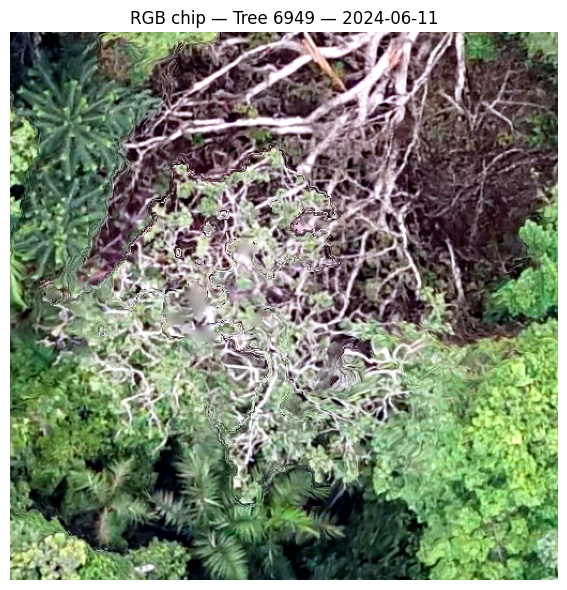


Done. Chip size: 512×512 px — read in seconds from a 50 GB file.


In [18]:
# ── Step 3: Read one RGB chip ─────────────────────────────────────────────────
target_cog = cog_list[0]   # first date — change index to see other dates
d = str(target_cog['date'])
label = f"{d[:4]}-{d[4:6]}-{d[6:]}"

print(f"Reading chip from: {label}")
print(f"File: {target_cog['href'].split('/')[-1]}")
print("Fetching from server (only ~800 KB, not the full 50 GB file) ...")

# src_crs matches the GeoPackage CRS — reprojected directly to COG CRS inside the function
arr, cog_crs = read_rgb_chip(
    target_cog['href'], TREE_X, TREE_Y, COG_USER, COG_PASS,
    src_crs=TREE_CRS
)

R, G, B = arr[0], arr[1], arr[2]

plt.figure(figsize=(6, 6))
plt.imshow(to_rgb(arr))
plt.title(f"RGB chip — Tree {TARGET_TREETAG} — {label}", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nDone. Chip size: {arr.shape[2]}×{arr.shape[1]} px — read in seconds from a 50 GB file.")

---
## Step 4 — Compute RGB vegetation indices

These three indices use only **Red, Green, Blue** bands — perfect for our drone RGB data.

| Index | Formula | What it measures |
|-------|---------|------------------|
| **GLI** — Green Leaf Index | `(2G − R − B) / (2G + R + B)` | Greenness of leaves; high = healthy |
| **VARI** — Visible Atmospherically Resistant Index | `(G − R) / (G + R − B)` | Robust greenness, less sensitive to haze |
| **GCC** — Green Chromatic Coordinate | `G / (R + G + B)` | Canopy phenology; tracks seasonal greenup/senescence |

**Dead trees → low GLI, low VARI, low GCC** (they show up red in the RdYlGn colourmap).

In [19]:
# ── Step 4: Compute GLI, VARI, GCC ────────────────────────────────────────────
eps = 1e-6
Rf, Gf, Bf = R.astype(float), G.astype(float), B.astype(float)

GLI  = (2*Gf - Rf - Bf) / (2*Gf + Rf + Bf + eps)
VARI = (Gf - Rf) / (Gf + Rf - Bf + eps)
VARI = np.clip(VARI, -1.5, 1.5)       # clip extreme values at shadows/water
GCC  = Gf / (Rf + Gf + Bf + eps)

print("Indices computed:")
print(f"  GLI  range: [{GLI.min():.3f}, {GLI.max():.3f}]  (healthy forest ≈ +0.1 to +0.4)")
print(f"  VARI range: [{VARI.min():.3f}, {VARI.max():.3f}]  (healthy ≈ 0.0 to +0.5)")
print(f"  GCC  range: [{GCC.min():.3f}, {GCC.max():.3f}]  (healthy ≈ 0.35 to 0.45)")

Indices computed:
  GLI  range: [-0.211, 0.950]  (healthy forest ≈ +0.1 to +0.4)
  VARI range: [-1.500, 1.500]  (healthy ≈ 0.0 to +0.5)
  GCC  range: [0.246, 0.951]  (healthy ≈ 0.35 to 0.45)


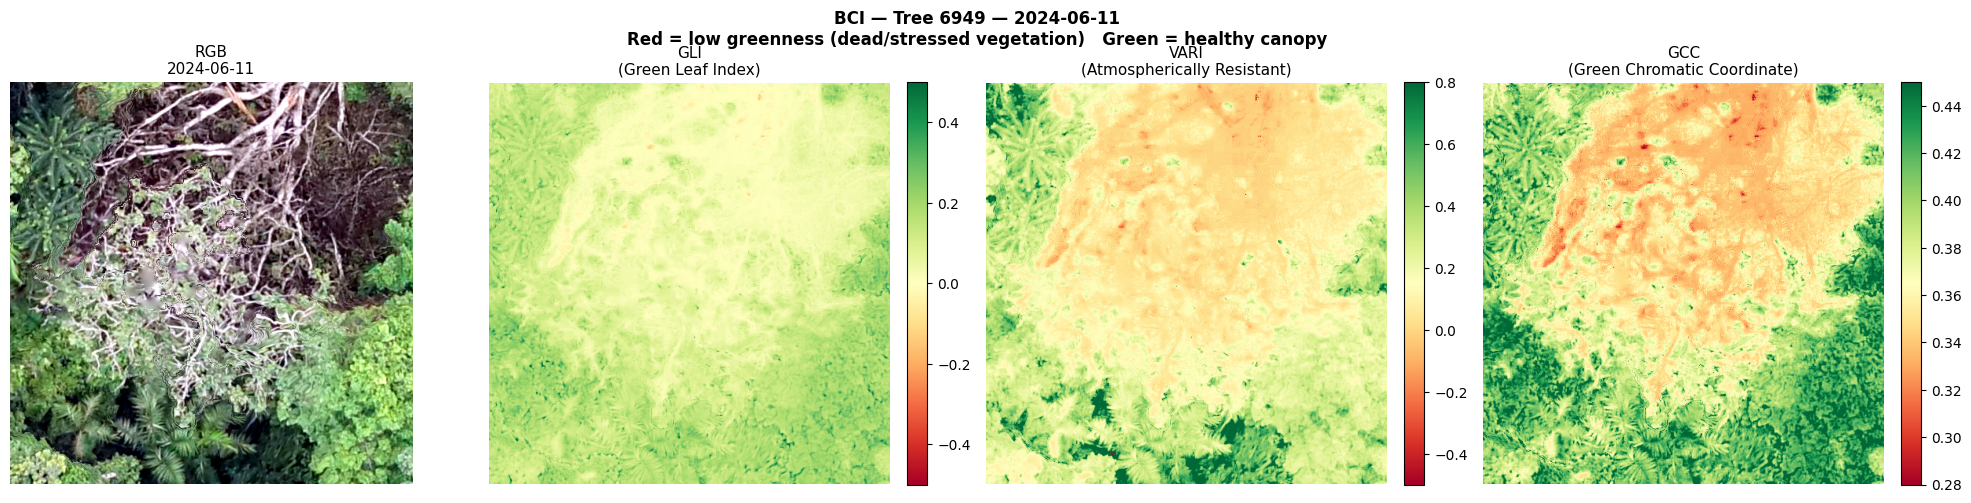

In [20]:
# ── Step 5: Side-by-side visualization ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(to_rgb(arr))
axes[0].set_title(f"RGB\n{label}", fontsize=11)
axes[0].axis('off')

index_specs = [
    (axes[1], GLI,  "GLI\n(Green Leaf Index)",                "RdYlGn", -0.5,  0.5),
    (axes[2], VARI, "VARI\n(Atmospherically Resistant)",      "RdYlGn", -0.5,  0.8),
    (axes[3], GCC,  "GCC\n(Green Chromatic Coordinate)",      "RdYlGn",  0.28, 0.45),
]

for ax, index, name, cmap, vmin, vmax in index_specs:
    im = ax.imshow(index, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(name, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    f"BCI — Tree {TARGET_TREETAG} — {label}\n"
    "Red = low greenness (dead/stressed vegetation)   Green = healthy canopy",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Step 6 — Track the dead tree across two dates

We now read the **same chip** from two dates and compare GLI maps.

**Healthy canopy** → stays green (high GLI).  
**Dead or dying tree** → turns red (low GLI) between the two dates.

Early date : 2024-06-11
Late  date : 2025-09-15
Reading both chips...


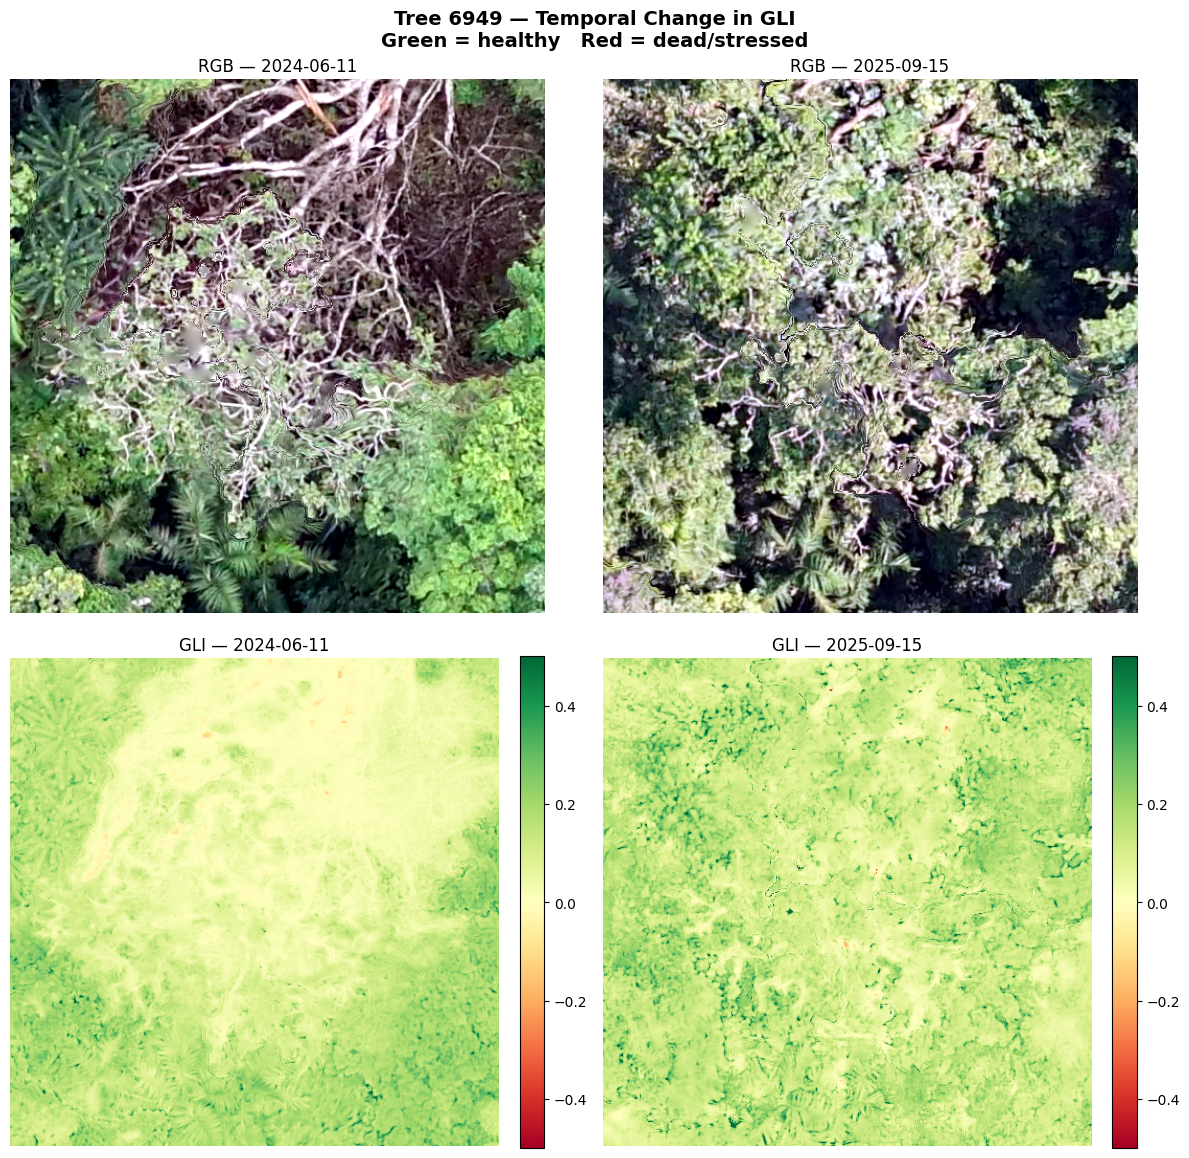

In [21]:
# ── Step 6: Two-date GLI comparison ──────────────────────────────────────────
date_early = cog_list[0]    # earliest available date
date_late  = cog_list[-1]   # latest available date

def fmt_date(c):
    d = str(c['date'])
    return f"{d[:4]}-{d[4:6]}-{d[6:]}"

print(f"Early date : {fmt_date(date_early)}")
print(f"Late  date : {fmt_date(date_late)}")
print("Reading both chips...")

arr_e, _ = read_rgb_chip(date_early['href'], TREE_X, TREE_Y, COG_USER, COG_PASS, src_crs=TREE_CRS)
arr_l, _ = read_rgb_chip(date_late['href'],  TREE_X, TREE_Y, COG_USER, COG_PASS, src_crs=TREE_CRS)

gli_e = compute_gli(arr_e)
gli_l = compute_gli(arr_l)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(to_rgb(arr_e))
axes[0, 0].set_title(f"RGB — {fmt_date(date_early)}", fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(to_rgb(arr_l))
axes[0, 1].set_title(f"RGB — {fmt_date(date_late)}", fontsize=12)
axes[0, 1].axis('off')

im1 = axes[1, 0].imshow(gli_e, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
axes[1, 0].set_title(f"GLI — {fmt_date(date_early)}", fontsize=12)
axes[1, 0].axis('off')
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)

im2 = axes[1, 1].imshow(gli_l, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
axes[1, 1].set_title(f"GLI — {fmt_date(date_late)}", fontsize=12)
axes[1, 1].axis('off')
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

fig.suptitle(
    f"Tree {TARGET_TREETAG} — Temporal Change in GLI\n"
    "Green = healthy   Red = dead/stressed",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## What just happened?

| Step | What we did | Data transferred |
|------|-------------|------------------|
| STAC query | Found all BCI RGB COGs for 2024 | ~15 KB |
| COG chip read (×2) | Read 512×512 px window centred on tree | ~800 KB each |
| Index computation | GLI, VARI, GCC | 0 bytes (local math) |

**The BCI whole-island RGB COG is 50+ GB.**  
We transferred less than 2 MB total — about **0.004% of the file**.

This is the power of **Cloud Optimized GeoTIFF + STAC**:
- **STAC** tells you *which* file and *where* to find it  
- **COG** lets you read *only the part you need*, from anywhere, with any tool